# KNN Classification on Pima Diabetes Dataset (MLOps Pipeline)
------------------------------------------------------------------------

In [45]:
## 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve, precision_recall_curve, auc
)
from imblearn.over_sampling import SMOTE
import joblib

In [46]:
## 2. Load Dataset
col_names = [
    'Pregnancies','Glucose','BloodPressure','SkinThickness',
    'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome'
]
data = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv",
    header=None, names=col_names
)
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [47]:
## 3. Data Preprocessing
print("\nZero values count per column:")
print((data==0).sum())


Zero values count per column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [48]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [49]:
cols_with_zero_invalid = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
data[cols_with_zero_invalid] = data[cols_with_zero_invalid].replace(0, np.nan)
data.fillna(data.median(), inplace=True)

In [50]:
print((data==0).sum())

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


<Axes: xlabel='Outcome', ylabel='count'>

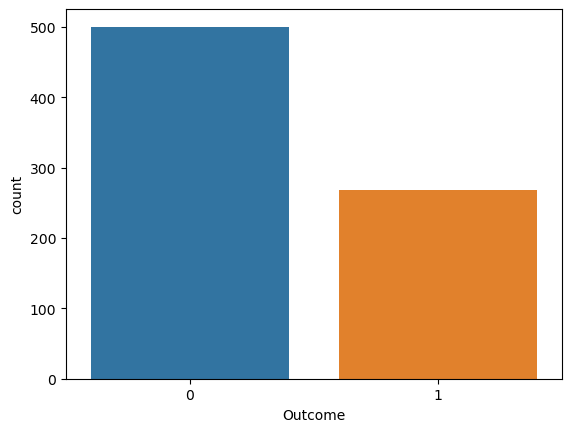

In [51]:
#Countng values of outcomes having 0 or 1, 0 means non diabetic and 1 means diabetic
sns.countplot(x='Outcome',data=data)

In [52]:
## 4. Feature Engineering / Selection

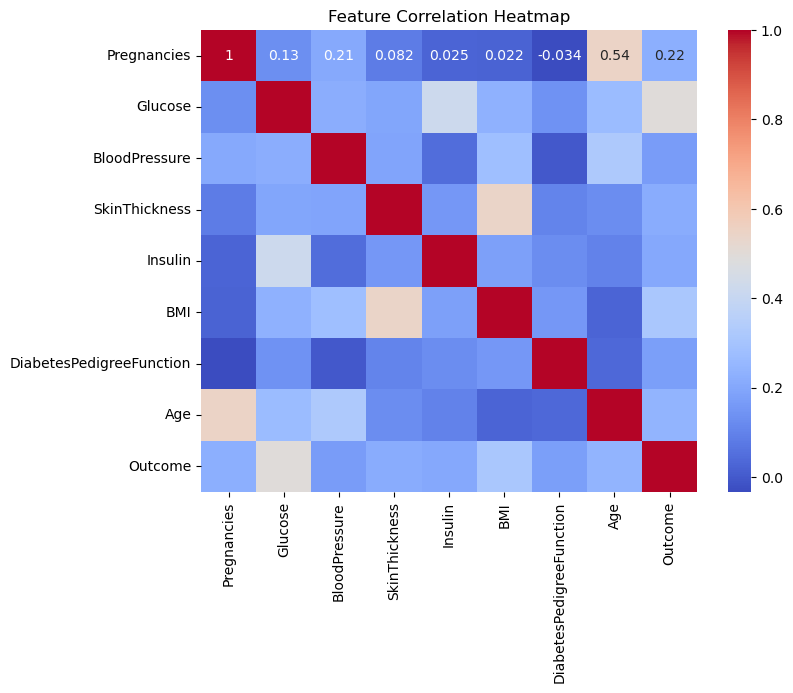

In [53]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [54]:
X = data.drop("Pregnancies", inplace= True,axis=1)

In [55]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

In [56]:
X

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,148.0,72.0,35.0,125.0,33.6,0.627,50
1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,183.0,64.0,29.0,125.0,23.3,0.672,32
3,89.0,66.0,23.0,94.0,28.1,0.167,21
4,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...
763,101.0,76.0,48.0,180.0,32.9,0.171,63
764,122.0,70.0,27.0,125.0,36.8,0.340,27
765,121.0,72.0,23.0,112.0,26.2,0.245,30
766,126.0,60.0,29.0,125.0,30.1,0.349,47


In [57]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [58]:
## 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [59]:
X_train.shape

(614, 7)

In [60]:
## 6. Scaling (StandardScaler vs MinMaxScaler)
scalers = {"StandardScaler": StandardScaler(), "MinMaxScaler": MinMaxScaler()}
results_scalers = {}

for scaler_name, scaler in scalers.items():
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    results_scalers[scaler_name] = f1

print("F1 Scores by Scaler:", results_scalers)
best_scaler_name = max(results_scalers, key=results_scalers.get)
print("Best scaler:", best_scaler_name)
scaler = scalers[best_scaler_name]
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

F1 Scores by Scaler: {'StandardScaler': 0.66, 'MinMaxScaler': 0.6153846153846154}
Best scaler: StandardScaler


In [61]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
cm

array([[82, 18],
       [22, 32]], dtype=int64)

In [62]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.82      0.80       100
           1       0.64      0.59      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



In [65]:
## 7. Handle Class Imbalance with SMOTE
print("Class distribution before SMOTE:", np.bincount(y_train))
smote = SMOTE(random_state=42)
X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)
print("Class distribution after SMOTE:", np.bincount(y_train))

Class distribution before SMOTE: [400 214]
Class distribution after SMOTE: [400 400]


In [66]:
## 8. Hyperparameter Tuning with GridSearchCV
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski", "cosine"],
    "p": [1, 2, 3]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

best_knn = grid_search.best_estimator_

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Parameters: {'metric': 'cosine', 'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
Best CV F1 Score: 0.829250751378637


In [72]:
## 9. Final Evaluation with Plots
y_pred = best_knn.predict(X_test_scaled)
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix\n",cm)
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion matrix
 [[74 26]
 [16 38]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.74      0.78       100
           1       0.59      0.70      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



In [68]:
## 10. Save Best Model & Scaler
joblib.dump(best_knn, "best_knn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Best tuned model and scaler saved!")

Best tuned model and scaler saved!


In [69]:
## 11. Prediction Pipeline
def predict_diabetes(input_data):
    model = joblib.load("best_knn_model.pkl")
    scaler = joblib.load("scaler.pkl")
    df = pd.DataFrame([input_data])
    df_scaled = scaler.transform(df)
    prediction = model.predict(df_scaled)
    return "Diabetic" if prediction[0] == 1 else "Non-Diabetic"

# Example prediction
user_data = {
    'Glucose': 130,
    'BloodPressure': 72,
    'SkinThickness': 30,
    'Insulin': 120,
    'BMI': 25.5,
    'DiabetesPedigreeFunction': 0.6,
    'Age': 40
}
print("Prediction for sample:", predict_diabetes(user_data))

Prediction for sample: Non-Diabetic
